In [ ]:
import pathlib

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

### Carga de Datos

In [ ]:
# cargamos datos
dataset_path = keras.utils.get_file("auto-mpg.data", "http://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data")
dataset_path

'C:\\Users\\doria\\.keras\\datasets\\auto-mpg.data'

In [ ]:
# nombre de las columnas
column_names = ['MPG','Cylinders','Displacement','Horsepower','Weight',
                'Acceleration', 'Model Year', 'Origin']

# cargamos los datos del csv
raw = pd.read_csv(dataset_path, names=column_names, na_values = "?", comment='\t', sep=" ", skipinitialspace=True)

# cargamos el dataset en data
data = raw.copy()
data.tail()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
393,27.0,4,140.0,86.0,2790.0,15.6,82,1
394,44.0,4,97.0,52.0,2130.0,24.6,82,2
395,32.0,4,135.0,84.0,2295.0,11.6,82,1
396,28.0,4,120.0,79.0,2625.0,18.6,82,1
397,31.0,4,119.0,82.0,2720.0,19.4,82,1


### Limpieza de Datos

In [ ]:
# limpiado de datos rapido
data = data.dropna()

# sacamos origin del dataset
origin = data.pop('Origin')

# creamos unas dummy variables (one-hot encoding)
data['USA'] = (origin == 1) * 1.0
data['Europe'] = (origin == 2) * 1.0
data['Japan'] = (origin == 3) * 1.0
data.tail()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,USA,Europe,Japan
393,27.0,4,140.0,86.0,2790.0,15.6,82,1.0,0.0,0.0
394,44.0,4,97.0,52.0,2130.0,24.6,82,0.0,1.0,0.0
395,32.0,4,135.0,84.0,2295.0,11.6,82,1.0,0.0,0.0
396,28.0,4,120.0,79.0,2625.0,18.6,82,1.0,0.0,0.0
397,31.0,4,119.0,82.0,2720.0,19.4,82,1.0,0.0,0.0


In [ ]:
# se crea el test and train set (80/20)
train = data.sample(frac=0.8,random_state=0)
test = data.drop(train.index)

# estadisticas
train_stats = train.describe()
train_stats.pop("MPG")
train_stats = train_stats.transpose()

In [ ]:
# variables Y
y_train = train.pop('MPG')
y_test  = test.pop('MPG')

In [ ]:
# normalizacion de datos
def norm(x):
    return (x - train_stats['mean']) / train_stats['std']

train = norm(train)
test = norm(test)

### Modelo de Regresion Neuronal

In [ ]:
# Modelo de regresion neuronal arquitectura NN regresion
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=[len(train.keys())]),
    #layers.BatchNormalization(),
    layers.Dense(64, activation='relu'),
    #layers.BatchNormalization(),
    layers.Dense(1)
  ])

# algoritmo de optimizacion lr = 0.001
optimizer = tf.keras.optimizers.RMSprop(0.001)

# se compila el modelo con Mean Square Error
model.compile(loss='mse', optimizer=optimizer, metrics=['mae', 'mse'])

# paciencia: cantidad de epochs para ver si mejora la cosa.
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10)

model.summary()

c:\Python\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,865 (19.00 KB)

 Trainable params: 4,865 (19.00 KB)

 Non-trainable params: 0 (0.00 B)

### Entrenamiento el Modelo con Callback

In [ ]:
#Entrenamiento el modelo con callback
# imprime el progreso (Keras Callback)
class PrintDot(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs):
        if epoch % 100 == 0: 
            print('')
            print("Epoch",epoch,'completed', end='')

EPOCHS = 1000

history = model.fit(train, y_train, epochs=EPOCHS, validation_split = 0.2, verbose=0, callbacks=[early_stop, PrintDot()])


Epoch 0 completed

### Evaluacion del Modelo de Regresion

In [ ]:
# informacion de entrenamiento de los ultimos 5 epochs
hist = pd.DataFrame(history.history)
hist['epoch'] = history.epoch
hist.tail()

,loss,mae,mse,val_loss,val_mae,val_mse,epoch
80,6.268056,1.749828,6.268056,7.334271,2.093018,7.334271,80
81,5.984995,1.706746,5.984995,7.527921,2.061956,7.527921,81
82,6.228097,1.745694,6.228097,7.413708,2.112341,7.413708,82
83,6.119050,1.715890,6.119050,7.462378,2.128559,7.462378,83
84,6.139630,1.738169,6.139630,7.424641,2.065226,7.424641,84


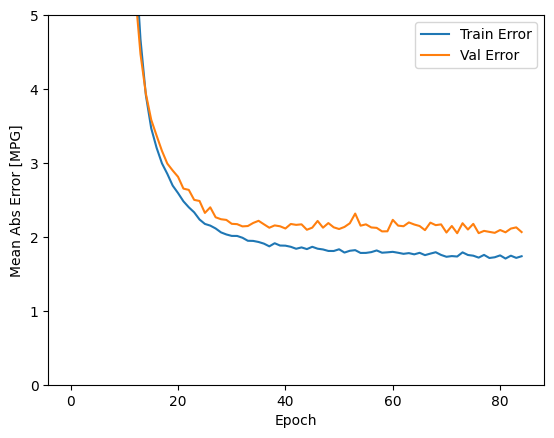

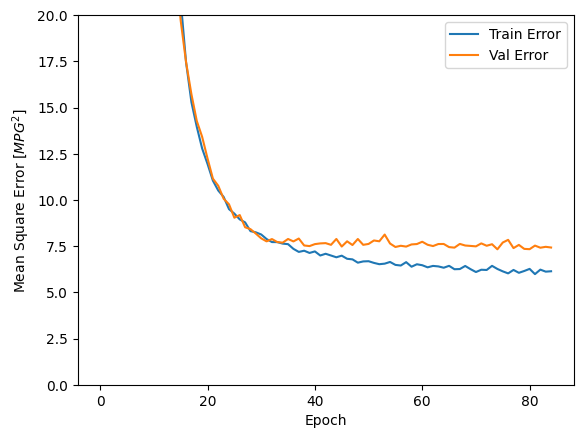

In [ ]:
# desplegar el rendimiento
hist = pd.DataFrame(history.history)
hist['epoch'] = history.epoch

plt.figure()
plt.xlabel('Epoch')
plt.ylabel('Mean Abs Error [MPG]')
plt.plot(hist['epoch'], hist['mae'],
       label='Train Error')
plt.plot(hist['epoch'], hist['val_mae'],
       label = 'Val Error')
plt.ylim([0,5])
plt.legend()

plt.figure()
plt.xlabel('Epoch')
plt.ylabel('Mean Square Error [$MPG^2$]')
plt.plot(hist['epoch'], hist['mse'],
       label='Train Error')
plt.plot(hist['epoch'], hist['val_mse'],
       label = 'Val Error')
plt.ylim([0,20])
plt.legend()
plt.show()


In [ ]:
# evaluacion del modelo
loss, mae, mse = model.evaluate(test, y_test, verbose=2)

print("Testing set Mean Abs Error: {:5.2f} MPG".format(mae))

3/3 - 0s - 32ms/step - loss: 5.5209 - mae: 1.8583 - mse: 5.5209
Testing set Mean Abs Error:  1.86 MPG


### Predicciones

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


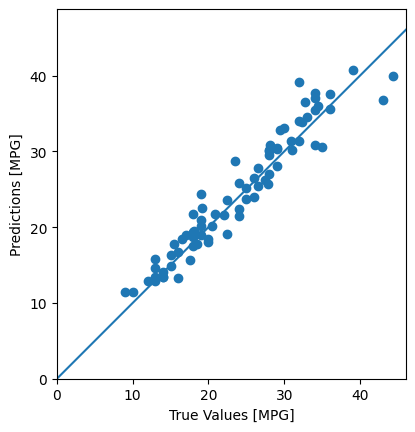

In [ ]:

pred = model.predict(test).flatten()

plt.scatter(y_test, pred)
plt.xlabel('True Values [MPG]')
plt.ylabel('Predictions [MPG]')
plt.axis('equal')
plt.axis('square')
plt.xlim([0,plt.xlim()[1]])
plt.ylim([0,plt.ylim()[1]])
_ = plt.plot([-100, 100], [-100, 100])

In [ ]:
# prediccion del primer auto 
pred = model.predict(test.iloc[0:1, :]).flatten()

print("Para un vehiculo con las siguientes caracteristicas:")
print(test.iloc[0, :])
print(" ")
print("Se predice un MPG de:", pred[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Para un vehiculo con las siguientes caracteristicas:
Cylinders       1.483887
Displacement    1.865988
Horsepower      2.234620
Weight          1.018782
Acceleration   -2.530891
Model Year     -1.604642
USA             0.774676
Europe         -0.465148
Japan          -0.495225
Name: 9, dtype: float64
 
Se predice un MPG de: 16.3106
